# Running State Identification (concise + 10-fold time-block CV)

Standalone example pack: run this notebook **from this folder** (Jupyter working directory = this directory). Data are in `data/`.

Classify running vs non-running from suite2p calcium traces (RandomForest). This notebook keeps the core pipeline and adds **contiguous time-block 10-fold cross-validation**: one temporal block is held out as the test set; a gap around the block is excluded from training to limit leakage from autocorrelation / median filtering; scaling is fit within each fold; SMOTE is off by default.


In [1]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.io
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from scipy.interpolate import interp1d
from scipy.signal import medfilt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

HERE = Path.cwd().resolve()

# plot style: Arial
from matplotlib import rcParams
rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Helvetica'],
    'axes.unicode_minus': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})
sns.set_theme(style='whitegrid', font='Arial')

# -------------------- paths / params --------------------
ROOT = HERE / "data"
PLANE_DIRS = [
    ROOT / "suite2p" / "Plane_17_motionfree" / "suite2p" / "plane0",
    ROOT / "suite2p" / "Plane_21_motionfree" / "suite2p" / "plane0",
    ROOT / "suite2p" / "Plane_25_motionfree" / "suite2p" / "plane0",
]
SPEED_CSV = ROOT / "Region2_file3_20231230_175745.csv"
MOTION_MAT = ROOT / "Motion_CA1run_R2f3.mat"

N_FRAMES = 4500          
RUNNING_THRESHOLD = 0.03 # mm/s
MEDFILT_WIN = 5
N_FOLDS = 10
GAP_FRAMES = 30          # exclude this many frames on each side of the test block
RF_PARAMS = dict(n_estimators=100, random_state=42, n_jobs=-1)
N_SHUFFLES = 50        # circular-shuffle null permutations
MIN_SHIFT_FRAC = 0.05  # min |shift| as fraction of n
RUN_CIRCULAR_SHUFFLE = True  # True to run the slow 50-shuffle null
PLANE_Z = [17, 21, 25]        # physical z of PLANE_DIRS[0..2]


In [2]:
def load_suite2p_plane(plane_dir: Path):
    plane_dir = Path(plane_dir)
    return (
        np.load(plane_dir / "F.npy", allow_pickle=True),
        np.load(plane_dir / "Fneu.npy", allow_pickle=True),
        np.load(plane_dir / "isCell.npy", allow_pickle=True),
        np.load(plane_dir / "stat.npy", allow_pickle=True),
    )


def load_running_speed(csv_path, target_len=6000, use_n=1997):
    data = pd.read_csv(csv_path)
    data[["Distance", "Speed"]] = data["Data"].str.split(";", expand=True)[[0, 1]]
    data = data[data["Speed"].notna()].copy()
    data["Time"] = pd.to_datetime(data["Time"], format="%Y%m%d_%H%M%S%f")
    data["Speed"] = pd.to_numeric(
        data["Speed"].str.replace("mm/s", "", regex=False).str.strip(), errors="coerce"
    ).abs()
    data["Time"] = (data["Time"] - data["Time"].iloc[0]).dt.total_seconds()

    t = data["Time"].iloc[:use_n].to_numpy()
    v = data["Speed"].iloc[:use_n].to_numpy()
    src = np.linspace(0, len(v) - 1, len(v))
    dst = np.linspace(0, len(v) - 1, target_len)
    return interp1d(src, t, kind="linear")(dst), interp1d(src, v, kind="linear")(dst)


def delete_non_cell_Substruct_Fneu(isCell, F, Fneu):
    """Keep suite2p ROIs with isCell > 0.5 and subtract neuropil (coeff 0.7)."""
    n_keep = int(sum(isCell[:, 0]))
    F_delete = np.zeros((n_keep, F.shape[1]))
    keys = []
    j = 0
    for i in range(len(isCell)):
        if isCell[i][0] > 0.5:
            F_delete[j] = F[i] - 0.7 * Fneu[i]
            keys.append(i)
            j += 1
    return F_delete, keys


def build_fluorescence(plane_dirs, medfilt_win=9):
    Fs, keys = [], []
    stats = []
    for d in plane_dirs:
        F, Fneu, isCell, stat = load_suite2p_plane(d)
        F_del, key = delete_non_cell_Substruct_Fneu(isCell, F, Fneu)
        for i in range(F_del.shape[0]):
            F_del[i] = medfilt(F_del[i], kernel_size=medfilt_win)
        Fs.append(F_del)
        keys.append(key)
        stats.append(stat)
    return np.concatenate(Fs, axis=0), keys, stats

def time_block_splits(n_samples, n_folds=10, gap=0):
    """Contiguous time-block CV: each fold holds out one temporal block.

    Train indices exclude a `gap` buffer on both sides of the test block
    to reduce leakage from temporal autocorrelation / median filtering.
    """
    edges = np.linspace(0, n_samples, n_folds + 1, dtype=int)
    for k in range(n_folds):
        test_start, test_end = edges[k], edges[k + 1]
        test_idx = np.arange(test_start, test_end)

        train_mask = np.ones(n_samples, dtype=bool)
        left = max(0, test_start - gap)
        right = min(n_samples, test_end + gap)
        train_mask[left:right] = False
        train_idx = np.where(train_mask)[0]
        yield train_idx, test_idx

def time_block_splits_by_frac(n_samples, block_frac=0.2, gap=0):
    """Hold out contiguous blocks of `block_frac` of the timeline (e.g. 20% -> 5 folds)."""
    block_size = max(1, int(round(n_samples * block_frac)))
    n_folds = max(1, n_samples // block_size)
    edges = np.linspace(0, n_samples, n_folds + 1, dtype=int)
    for k in range(n_folds):
        test_start, test_end = edges[k], edges[k + 1]
        test_idx = np.arange(test_start, test_end)
        train_mask = np.ones(n_samples, dtype=bool)
        left = max(0, test_start - gap)
        right = min(n_samples, test_end + gap)
        train_mask[left:right] = False
        yield np.where(train_mask)[0], test_idx


def make_rf_pipeline(use_smote=False):
    """Scaler -> (optional SMOTE) -> RandomForest. SMOTE is train-only in the pipeline."""
    steps = [("scaler", StandardScaler())]
    if use_smote:
        steps.append(("smote", SMOTE(random_state=42)))
        return ImbPipeline(steps + [("clf", RandomForestClassifier(**RF_PARAMS))])
    return Pipeline(steps + [("clf", RandomForestClassifier(**RF_PARAMS))])


def run_timeblock_cv(
    X_feat, y, splits, gap=GAP_FRAMES, verbose=False, return_importances=False,
    use_smote=False,
):
    """Fit RF on each train block; evaluate on held-out test block."""
    rows, y_true_list, y_pred_list, importances = [], [], [], []
    for fold, (train_idx, test_idx) in enumerate(splits):
        est = make_rf_pipeline(use_smote=use_smote)
        est.fit(X_feat[train_idx], y[train_idx])
        y_hat = est.predict(X_feat[test_idx])
        rows.append(dict(
            fold=fold + 1,
            test_start=int(test_idx[0]),
            test_end=int(test_idx[-1]) + 1,
            test_frac=(len(test_idx) / len(y)),
            n_train=len(train_idx),
            n_test=len(test_idx),
            run_frac=float(y[test_idx].mean()),
            accuracy=accuracy_score(y[test_idx], y_hat),
            precision=precision_score(y[test_idx], y_hat, zero_division=0),
            recall=recall_score(y[test_idx], y_hat, zero_division=0),
            f1=f1_score(y[test_idx], y_hat, zero_division=0),
        ))
        y_true_list.append(y[test_idx])
        y_pred_list.append(y_hat)
        importances.append(est.named_steps["clf"].feature_importances_)
        if verbose:
            r = rows[-1]
            print(
                f"  fold {r['fold']:d} | [{r['test_start']}, {r['test_end']}) | "
                f"run%={r['run_frac']:.3f} | acc={r['accuracy']:.3f} f1={r['f1']:.3f}"
            )
    out = (
        pd.DataFrame(rows),
        np.concatenate(y_true_list),
        np.concatenate(y_pred_list),
    )
    if return_importances:
        return out + (importances,)
    return out

def circular_shift_labels(y, shift):
    """Circularly shift labels; preserves temporal autocorrelation of y."""
    return np.roll(y, int(shift))


def sample_circular_shifts(n_samples, n_shuffles, min_shift, rng):
    """Random circular shifts with |shift| >= min_shift."""
    min_shift = max(1, int(min_shift))
    max_shift = n_samples - min_shift
    if max_shift <= min_shift:
        raise ValueError("min_shift too large for n_samples")
    pool = np.arange(min_shift, max_shift + 1)
    if len(pool) >= n_shuffles:
        return rng.choice(pool, size=n_shuffles, replace=False)
    return rng.choice(pool, size=n_shuffles, replace=True)


def run_circular_shuffle_null(
    X_feat, y_true, n_shuffles=50, n_folds=10, gap=30,
    min_shift_frac=0.05, random_state=0, verbose=True,
):
    """Null distribution: fix X, circularly shift y, repeat time-block CV."""
    rng = np.random.default_rng(random_state)
    n = len(y_true)
    min_shift = max(1, int(round(n * min_shift_frac)))
    shifts = sample_circular_shifts(n, n_shuffles, min_shift, rng)

    null_rows = []
    for i, shift in enumerate(shifts):
        y_shuf = circular_shift_labels(y_true, shift)
        splits = time_block_splits(n, n_folds, gap)
        m_df, _, _ = run_timeblock_cv(X_feat, y_shuf, splits, verbose=False)
        null_rows.append(dict(
            shuffle=i + 1,
            shift=int(shift),
            accuracy=m_df["accuracy"].mean(),
            f1=m_df["f1"].mean(),
            precision=m_df["precision"].mean(),
            recall=m_df["recall"].mean(),
        ))
        if verbose and ((i + 1) % 10 == 0 or i == 0 or i + 1 == n_shuffles):
            r = null_rows[-1]
            print(
                f"  shuffle {i+1:3d}/{n_shuffles} | shift={r['shift']:4d} | "
                f"acc={r['accuracy']:.3f} f1={r['f1']:.3f}"
            )
    return pd.DataFrame(null_rows)


def null_pvalue(real_score, null_scores):
    """One-sided p: P(null >= real), with +1 correction."""
    null_scores = np.asarray(null_scores, dtype=float)
    return (1.0 + np.sum(null_scores >= real_score)) / (len(null_scores) + 1.0)


X: (4500, 190), y: (4500,), running fraction: 0.382


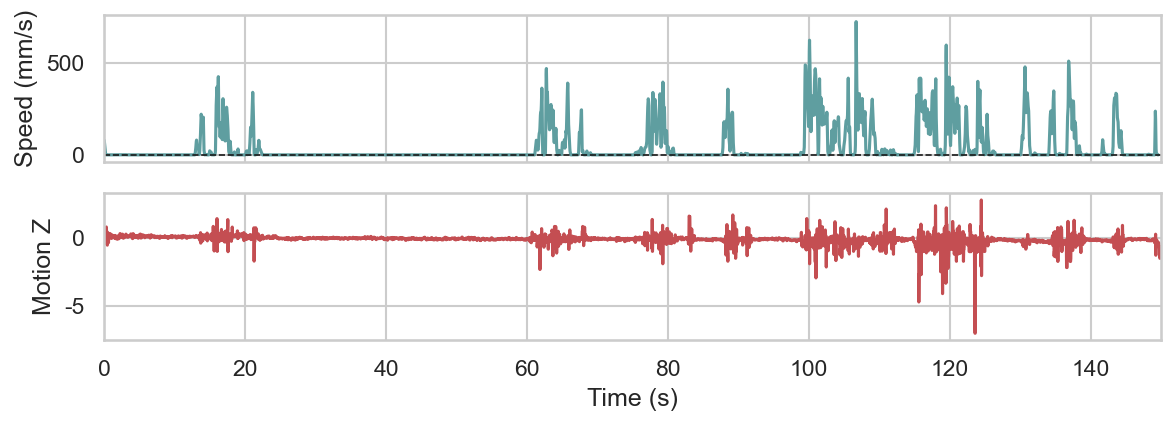

In [3]:
# -------------------- load & preprocess --------------------
Delete_F, plane_keys, plane_stats = build_fluorescence(PLANE_DIRS, MEDFILT_WIN)
Running_Time, Running_Speed = load_running_speed(SPEED_CSV)

# binary label: running vs not
y = (Running_Speed[:N_FRAMES] > RUNNING_THRESHOLD).astype(int)
X = Delete_F[:, :N_FRAMES].T  # (time, neurons)

print(f"X: {X.shape}, y: {y.shape}, running fraction: {y.mean():.3f}")

# optional motion (for quick sanity plot)
if MOTION_MAT.exists():
    mat = scipy.io.loadmat(MOTION_MAT)
    Delta_Z = medfilt(-mat["Delta"][2, :], 3)
    t_motion = np.linspace(0, 150, 4500)
    fig, axs = plt.subplots(2, 1, figsize=(8, 3), sharex=True, dpi=150)
    axs[0].plot(Running_Time[:N_FRAMES], Running_Speed[:N_FRAMES], color="cadetblue")
    axs[0].axhline(RUNNING_THRESHOLD, color="k", ls="--", lw=0.8)
    axs[0].set_ylabel("Speed (mm/s)")
    axs[1].plot(t_motion, Delta_Z[:4500], color="r")
    axs[1].set_ylabel("Motion Z")
    axs[1].set_xlabel("Time (s)")
    axs[1].set_xlim(0, 150)
    plt.tight_layout()
    plt.show()


In [4]:
# -------------------- 10-fold contiguous time-block CV (no SMOTE) --------------------
# Split timeline into 10 equal blocks; each fold tests one block.
# GAP_FRAMES around the test block are removed from train (not used as test either).
fold_metrics = []
y_true_all, y_pred_all = [], []
importances = []
estimators = []

print(
    f"{N_FOLDS}-fold time-block CV | NO SMOTE | n={len(y)}, "
    f"block~{len(y)//N_FOLDS} frames, gap={GAP_FRAMES} each side"
)
print("Fold | test frames       | n_train | n_test | run%_test | acc   | prec  | rec   | f1")
print("-" * 90)

for fold, (train_idx, test_idx) in enumerate(time_block_splits(len(y), N_FOLDS, GAP_FRAMES)):
    est = make_rf_pipeline(use_smote=False)
    est.fit(X[train_idx], y[train_idx])
    y_hat = est.predict(X[test_idx])

    m = dict(
        fold=fold + 1,
        test_start=int(test_idx[0]),
        test_end=int(test_idx[-1]) + 1,
        n_train=len(train_idx),
        n_test=len(test_idx),
        run_frac=float(y[test_idx].mean()),
        accuracy=accuracy_score(y[test_idx], y_hat),
        precision=precision_score(y[test_idx], y_hat, zero_division=0),
        recall=recall_score(y[test_idx], y_hat, zero_division=0),
        f1=f1_score(y[test_idx], y_hat, zero_division=0),
    )
    fold_metrics.append(m)
    y_true_all.append(y[test_idx])
    y_pred_all.append(y_hat)
    importances.append(est.named_steps["clf"].feature_importances_)
    estimators.append(est)

    print(
        f"{m['fold']:4d} | [{m['test_start']:4d}, {m['test_end']:4d}) | "
        f"{m['n_train']:7d} | {m['n_test']:6d} | {m['run_frac']:8.3f} | "
        f"{m['accuracy']:.3f} | {m['precision']:.3f} | {m['recall']:.3f} | {m['f1']:.3f}"
    )

metrics_df = pd.DataFrame(fold_metrics)
print("\nMean +/- std across folds (no SMOTE):")
for col in ["accuracy", "precision", "recall", "f1"]:
    print(f"  {col:10s}: {metrics_df[col].mean():.3f} +/- {metrics_df[col].std():.3f}")


10-fold time-block CV | NO SMOTE | n=4500, block~450 frames, gap=30 each side
Fold | test frames       | n_train | n_test | run%_test | acc   | prec  | rec   | f1
------------------------------------------------------------------------------------------
   1 | [   0,  450) |    4020 |    450 |    0.202 | 0.747 | 0.361 | 0.330 | 0.345
   2 | [ 450,  900) |    3990 |    450 |    0.387 | 0.791 | 0.926 | 0.500 | 0.649
   3 | [ 900, 1350) |    3990 |    450 |    0.000 | 1.000 | 0.000 | 0.000 | 0.000
   4 | [1350, 1800) |    3990 |    450 |    0.000 | 1.000 | 0.000 | 0.000 | 0.000
   5 | [1800, 2250) |    3990 |    450 |    0.438 | 0.767 | 0.803 | 0.619 | 0.699
   6 | [2250, 2700) |    3990 |    450 |    0.473 | 0.829 | 0.840 | 0.789 | 0.814
   7 | [2700, 3150) |    3990 |    450 |    0.442 | 0.876 | 0.799 | 0.960 | 0.872
   8 | [3150, 3600) |    3990 |    450 |    0.760 | 0.771 | 0.875 | 0.816 | 0.844
   9 | [3600, 4050) |    3990 |    450 |    0.636 | 0.778 | 0.912 | 0.720 | 0.805
  10 | [

Classification report (pooled time-block OOF, no SMOTE):
              precision    recall  f1-score   support

 Not Running       0.84      0.91      0.87      2781
     Running       0.83      0.71      0.77      1719

    accuracy                           0.83      4500
   macro avg       0.83      0.81      0.82      4500
weighted avg       0.83      0.83      0.83      4500

saved F:\我的资料库_更新\软件\Python\2023-05 MultiViewTwoPhoton\ActivityAnalysisAndPlot\LinearRunner\RunningSpeed_identify_manual_cv_pack\confusion_matrix_nosmote.png
saved F:\我的资料库_更新\软件\Python\2023-05 MultiViewTwoPhoton\ActivityAnalysisAndPlot\LinearRunner\RunningSpeed_identify_manual_cv_pack\confusion_matrix_nosmote.svg


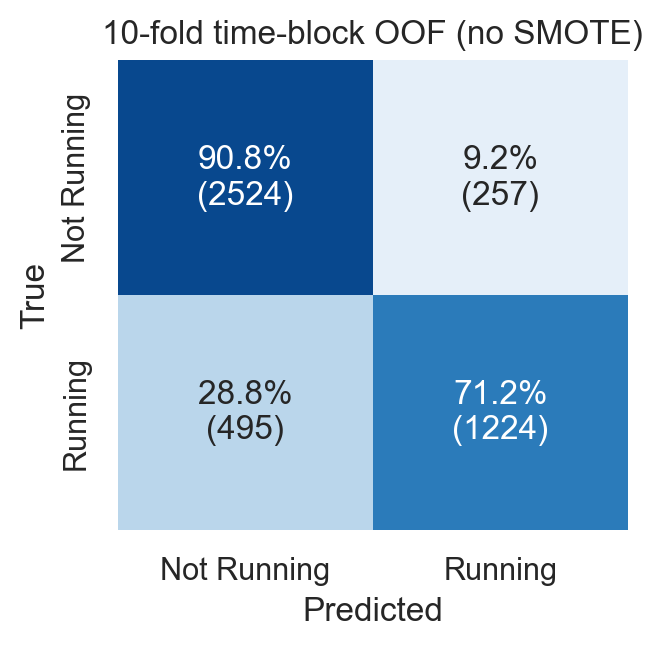

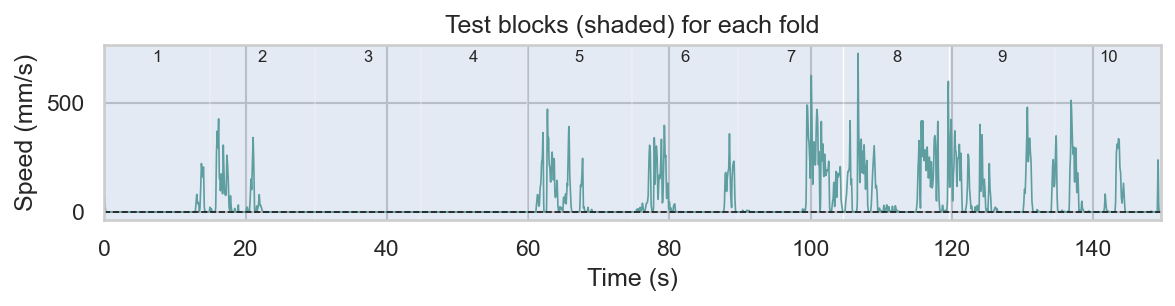

In [5]:
# -------------------- pooled OOF confusion / report (no SMOTE) --------------------
y_true_all = np.concatenate(y_true_all)
y_pred_all = np.concatenate(y_pred_all)

print("Classification report (pooled time-block OOF, no SMOTE):")
print(classification_report(y_true_all, y_pred_all, target_names=["Not Running", "Running"]))

cm = confusion_matrix(y_true_all, y_pred_all)
cm_pct = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1) * 100
annot = np.array([
    [f"{v:.1f}%\n({cm[i, j]})" for j, v in enumerate(row)]
    for i, row in enumerate(cm_pct)
])

fig, ax = plt.subplots(figsize=(3.4, 3.4), dpi=200)
sns.heatmap(cm_pct, annot=annot, fmt="", cmap="Blues", cbar=False, ax=ax, vmin=0, vmax=100)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticklabels(["Not Running", "Running"])
ax.set_yticklabels(["Not Running", "Running"], va="center")
ax.set_title(f"{N_FOLDS}-fold time-block OOF (no SMOTE)")
plt.tight_layout()
cm_png = Path("confusion_matrix_nosmote.png")
cm_svg = Path("confusion_matrix_nosmote.svg")
plt.savefig(cm_png, dpi=300, bbox_inches="tight")
plt.savefig(cm_svg, bbox_inches="tight")
print(f"saved {cm_png.resolve()}")
print(f"saved {cm_svg.resolve()}")
plt.show()

# visualize which time segments were held out
fig, ax = plt.subplots(figsize=(8, 2.2), dpi=150)
ax.plot(Running_Time[:N_FRAMES], Running_Speed[:N_FRAMES], color="cadetblue", lw=0.8)
ax.axhline(RUNNING_THRESHOLD, color="k", ls="--", lw=0.8)
for _, row in metrics_df.iterrows():
    ax.axvspan(
        Running_Time[int(row.test_start)],
        Running_Time[min(int(row.test_end), N_FRAMES) - 1],
        alpha=0.15,
    )
    ax.text(
        Running_Time[(int(row.test_start) + int(row.test_end) - 1) // 2],
        ax.get_ylim()[1] * 0.9 if ax.get_ylim()[1] else 1,
        str(int(row.fold)),
        ha="center",
        fontsize=8,
    )
ax.set_xlabel("Time (s)")
ax.set_ylabel("Speed (mm/s)")
ax.set_title("Test blocks (shaded) for each fold")
ax.set_xlim(Running_Time[0], Running_Time[N_FRAMES - 1])
plt.tight_layout()
plt.show()


## Circular-shuffle null distribution

Fix neural activity **X**; circularly shift running labels **y** by random lags (|shift| ≥ 5% of timeline). This preserves label autocorrelation while breaking the X–y relationship. Repeat the same 10-fold time-block CV for each shuffle to build a null distribution of accuracy/F1; compare to real labels with a one-sided p-value: `(1 + #{null ≥ real}) / (N + 1)`.

**Default skipped** (`RUN_CIRCULAR_SHUFFLE = False`) because 50 shuffles × 10-fold CV is slow. Set the flag to `True` in the params cell to run.


Real CV: acc=0.833, f1=0.576
Circular shuffle null: N=50, min_shift=225 frames (5% of n), same 10-fold time-block CV
  shuffle   1/50 | shift=1845 | acc=0.610 f1=0.159
  shuffle  10/50 | shift=2029 | acc=0.564 f1=0.150
  shuffle  20/50 | shift=3600 | acc=0.595 f1=0.176
  shuffle  30/50 | shift=3955 | acc=0.588 f1=0.237
  shuffle  40/50 | shift=3690 | acc=0.561 f1=0.132
  shuffle  50/50 | shift=3567 | acc=0.567 f1=0.135

Null summary:
  accuracy: null mean=0.579 +/- 0.032 | real=0.833 | p=0.0196
  f1      : null mean=0.175 +/- 0.055 | real=0.576 | p=0.0196
saved F:\我的资料库_更新\软件\Python\2023-05 MultiViewTwoPhoton\ActivityAnalysisAndPlot\LinearRunner\RunningSpeed_identify_manual_cv_pack\circular_shuffle_null.png
saved F:\我的资料库_更新\软件\Python\2023-05 MultiViewTwoPhoton\ActivityAnalysisAndPlot\LinearRunner\RunningSpeed_identify_manual_cv_pack\circular_shuffle_null.svg


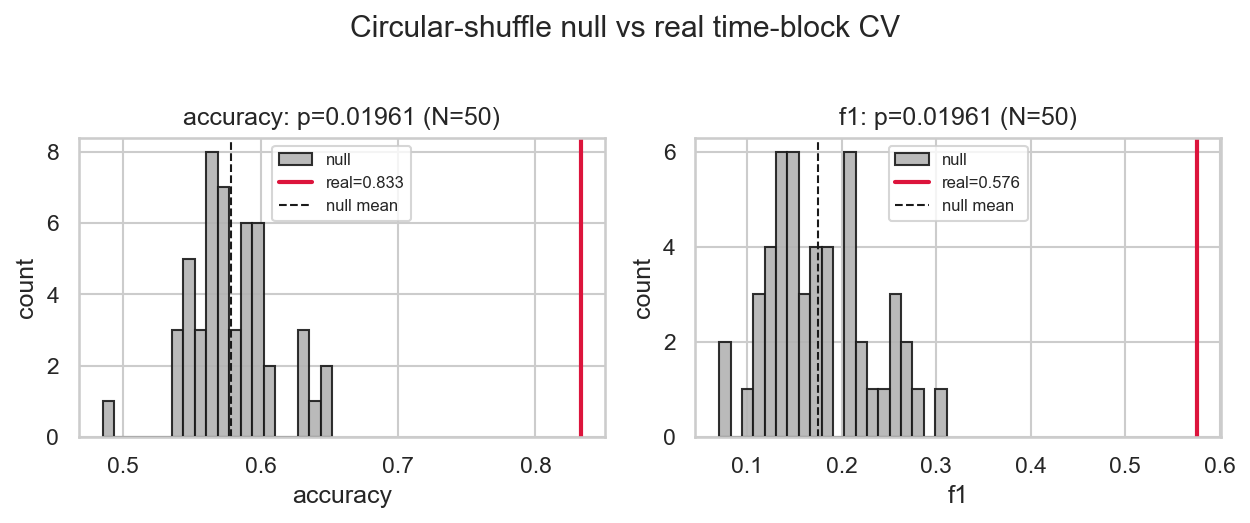


Significance table:
  metric   real  null_mean  null_std  p_value  n_shuffles
accuracy 0.8329     0.5786    0.0317   0.0196          50
      f1 0.5760     0.1751    0.0550   0.0196          50


In [6]:
# -------------------- circular-shuffle null distribution --------------------
if not RUN_CIRCULAR_SHUFFLE:
    print("Skipping circular-shuffle null (set RUN_CIRCULAR_SHUFFLE=True to run).")
else:
    real_acc = float(metrics_df["accuracy"].mean())
    real_f1 = float(metrics_df["f1"].mean())
    print(f"Real CV: acc={real_acc:.3f}, f1={real_f1:.3f}")
    print(
        f"Circular shuffle null: N={N_SHUFFLES}, "
        f"min_shift={max(1, int(round(len(y) * MIN_SHIFT_FRAC)))} frames "
        f"({MIN_SHIFT_FRAC:.0%} of n), same {N_FOLDS}-fold time-block CV"
    )

    null_df = run_circular_shuffle_null(
        X, y,
        n_shuffles=N_SHUFFLES,
        n_folds=N_FOLDS,
        gap=GAP_FRAMES,
        min_shift_frac=MIN_SHIFT_FRAC,
        random_state=42,
        verbose=True,
    )

    p_acc = null_pvalue(real_acc, null_df["accuracy"])
    p_f1 = null_pvalue(real_f1, null_df["f1"])

    print("\nNull summary:")
    print(
        f"  accuracy: null mean={null_df['accuracy'].mean():.3f} "
        f"+/- {null_df['accuracy'].std():.3f} | "
        f"real={real_acc:.3f} | p={p_acc:.4f}"
    )
    print(
        f"  f1      : null mean={null_df['f1'].mean():.3f} "
        f"+/- {null_df['f1'].std():.3f} | "
        f"real={real_f1:.3f} | p={p_f1:.4f}"
    )

    fig, axs = plt.subplots(1, 2, figsize=(8.5, 3.4), dpi=150)
    for ax, col, real, p in zip(
        axs, ["accuracy", "f1"], [real_acc, real_f1], [p_acc, p_f1]
    ):
        ax.hist(null_df[col], bins=20, color="0.7", edgecolor="k", alpha=0.9, label="null")
        ax.axvline(real, color="crimson", lw=2, label=f"real={real:.3f}")
        ax.axvline(null_df[col].mean(), color="k", ls="--", lw=1, label="null mean")
        ax.set_xlabel(col)
        ax.set_ylabel("count")
        ax.set_title(f"{col}: p={p:.4g} (N={len(null_df)})")
        ax.legend(fontsize=8)

    plt.suptitle("Circular-shuffle null vs real time-block CV", y=1.02)
    plt.tight_layout()
    out_png = Path("circular_shuffle_null.png")
    out_svg = Path("circular_shuffle_null.svg")
    plt.savefig(out_png, dpi=200, bbox_inches="tight")
    plt.savefig(out_svg, bbox_inches="tight")
    print(f"saved {out_png.resolve()}")
    print(f"saved {out_svg.resolve()}")
    plt.show()

    null_df.to_csv("circular_shuffle_null.csv", index=False)
    sig_df = pd.DataFrame([
        {"metric": "accuracy", "real": real_acc,
         "null_mean": null_df["accuracy"].mean(), "null_std": null_df["accuracy"].std(),
         "p_value": p_acc, "n_shuffles": len(null_df)},
        {"metric": "f1", "real": real_f1,
         "null_mean": null_df["f1"].mean(), "null_std": null_df["f1"].std(),
         "p_value": p_f1, "n_shuffles": len(null_df)},
    ])
    sig_df.to_csv("circular_shuffle_significance.csv", index=False)
    print("\nSignificance table:")
    print(sig_df.round(4).to_string(index=False))


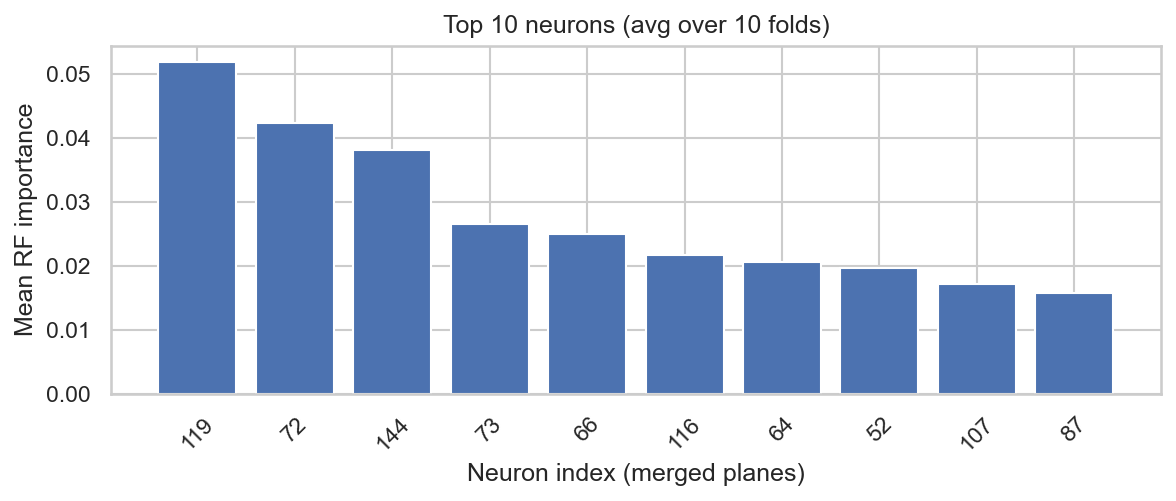

Top neurons: [(119, 0.0518), (72, 0.0422), (144, 0.038), (73, 0.0265), (66, 0.0249), (116, 0.0217), (64, 0.0206), (52, 0.0196), (107, 0.0172), (87, 0.0157)]


In [7]:
# -------------------- feature importance (mean over folds) --------------------
mean_imp = np.mean(importances, axis=0)
top_k = 10
top_idx = np.argsort(mean_imp)[::-1][:top_k]

plt.figure(figsize=(8, 3.5), dpi=150)
plt.bar(range(top_k), mean_imp[top_idx])
plt.xticks(range(top_k), top_idx, rotation=45)
plt.xlabel("Neuron index (merged planes)")
plt.ylabel("Mean RF importance")
plt.title(f"Top {top_k} neurons (avg over {N_FOLDS} folds)")
plt.tight_layout()
plt.show()

print("Top neurons:", list(zip(top_idx.tolist(), np.round(mean_imp[top_idx], 4).tolist())))


Baseline (all 190 neurons): acc=0.833, f1=0.576

Drop top 1 | keep 189 | dropped=[119]
  fold 1 | [0, 450) | run%=0.202 | acc=0.751 f1=0.378
  fold 2 | [450, 900) | run%=0.387 | acc=0.793 f1=0.667
  fold 3 | [900, 1350) | run%=0.000 | acc=1.000 f1=0.000
  fold 4 | [1350, 1800) | run%=0.000 | acc=1.000 f1=0.000
  fold 5 | [1800, 2250) | run%=0.438 | acc=0.756 f1=0.667
  fold 6 | [2250, 2700) | run%=0.473 | acc=0.844 f1=0.830
  fold 7 | [2700, 3150) | run%=0.442 | acc=0.873 f1=0.870
  fold 8 | [3150, 3600) | run%=0.760 | acc=0.780 f1=0.852
  fold 9 | [3600, 4050) | run%=0.636 | acc=0.784 f1=0.812
  fold 10 | [4050, 4500) | run%=0.482 | acc=0.769 f1=0.726
  -> acc=0.835+/-0.095, f1=0.580+/-0.337

Drop top 5 | keep 185 | dropped=[119, 72, 144, 73, 66]
  fold 1 | [0, 450) | run%=0.202 | acc=0.740 f1=0.316
  fold 2 | [450, 900) | run%=0.387 | acc=0.722 f1=0.498
  fold 3 | [900, 1350) | run%=0.000 | acc=1.000 f1=0.000
  fold 4 | [1350, 1800) | run%=0.000 | acc=1.000 f1=0.000
  fold 5 | [1800,

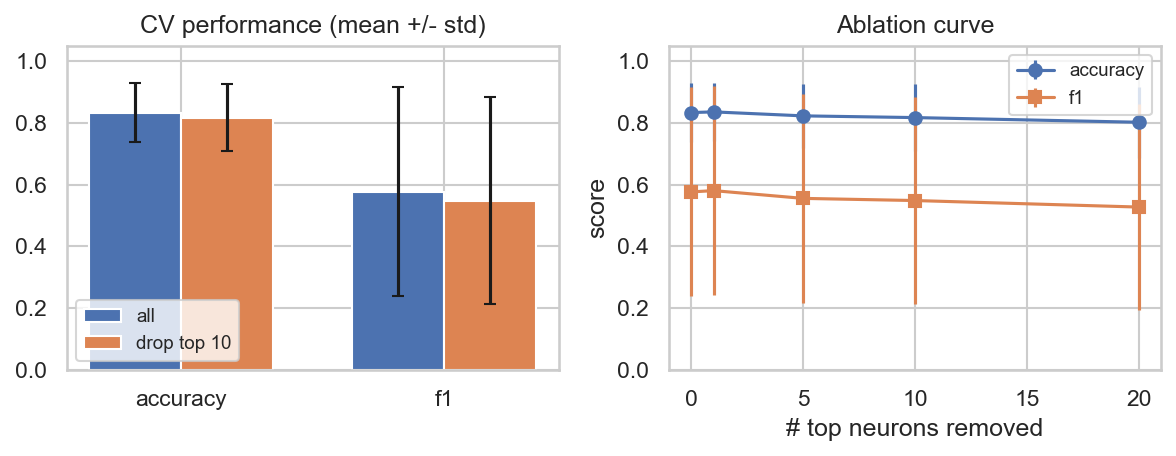


Drop top 10 pooled report:
              precision    recall  f1-score   support

 Not Running       0.82      0.90      0.86      2781
     Running       0.81      0.69      0.74      1719

    accuracy                           0.82      4500
   macro avg       0.81      0.79      0.80      4500
weighted avg       0.82      0.82      0.81      4500



In [8]:
# -------------------- ablation: remove top neurons, re-run time-block CV --------------------
# uses run_timeblock_cv() defined above

# how many top neurons to drop (can edit)
N_REMOVE_LIST = sorted(set([1, 5, 10, 20, top_k]))
n_neurons = X.shape[1]
ranked = np.argsort(mean_imp)[::-1]  # most important first

ablation_rows = [{
    "n_remove": 0,
    "n_keep": n_neurons,
    "accuracy": metrics_df["accuracy"].mean(),
    "accuracy_std": metrics_df["accuracy"].std(),
    "f1": metrics_df["f1"].mean(),
    "f1_std": metrics_df["f1"].std(),
    "precision": metrics_df["precision"].mean(),
    "recall": metrics_df["recall"].mean(),
}]

print(f"Baseline (all {n_neurons} neurons): "
      f"acc={ablation_rows[0]['accuracy']:.3f}, f1={ablation_rows[0]['f1']:.3f}")

ablation_detail = {}  # n_remove -> (metrics_df, y_true, y_pred)
for n_remove in N_REMOVE_LIST:
    drop = ranked[:n_remove]
    keep = np.setdiff1d(np.arange(n_neurons), drop)
    print(f"\nDrop top {n_remove} | keep {len(keep)} | dropped={drop.tolist()}")
    m_df, yt, yp = run_timeblock_cv(
        X[:, keep], y,
        time_block_splits(len(y), N_FOLDS, GAP_FRAMES),
        verbose=True,
    )
    ablation_detail[n_remove] = (m_df, yt, yp)
    ablation_rows.append({
        "n_remove": n_remove,
        "n_keep": len(keep),
        "accuracy": m_df["accuracy"].mean(),
        "accuracy_std": m_df["accuracy"].std(),
        "f1": m_df["f1"].mean(),
        "f1_std": m_df["f1"].std(),
        "precision": m_df["precision"].mean(),
        "recall": m_df["recall"].mean(),
    })
    print(f"  -> acc={m_df['accuracy'].mean():.3f}+/-{m_df['accuracy'].std():.3f}, "
          f"f1={m_df['f1'].mean():.3f}+/-{m_df['f1'].std():.3f}")

ablation_df = pd.DataFrame(ablation_rows)
print("\nSummary:")
print(ablation_df.round(3).to_string(index=False))

# compare baseline vs drop top_k
drop_k = top_k
m_drop, yt_drop, yp_drop = ablation_detail[drop_k]
base_acc, base_f1 = metrics_df["accuracy"].mean(), metrics_df["f1"].mean()
drop_acc, drop_f1 = m_drop["accuracy"].mean(), m_drop["f1"].mean()
print(f"\nChange after dropping top {drop_k}: "
      f"acc {base_acc:.3f} -> {drop_acc:.3f} ({drop_acc - base_acc:+.3f}), "
      f"f1 {base_f1:.3f} -> {drop_f1:.3f} ({drop_f1 - base_f1:+.3f})")

fig, axs = plt.subplots(1, 2, figsize=(8, 3.2), dpi=150)
x_pos = np.arange(2)
w = 0.35
axs[0].bar(x_pos - w / 2,
           [base_acc, base_f1], w,
           yerr=[metrics_df["accuracy"].std(), metrics_df["f1"].std()],
           label="all", capsize=3)
axs[0].bar(x_pos + w / 2,
           [drop_acc, drop_f1], w,
           yerr=[m_drop["accuracy"].std(), m_drop["f1"].std()],
           label=f"drop top {drop_k}", capsize=3)
axs[0].set_xticks(x_pos)
axs[0].set_xticklabels(["accuracy", "f1"])
axs[0].set_ylim(0, 1.05)
axs[0].legend(fontsize=9)
axs[0].set_title("CV performance (mean +/- std)")

axs[1].errorbar(
    ablation_df["n_remove"], ablation_df["accuracy"],
    yerr=ablation_df["accuracy_std"], marker="o", label="accuracy",
)
axs[1].errorbar(
    ablation_df["n_remove"], ablation_df["f1"],
    yerr=ablation_df["f1_std"], marker="s", label="f1",
)
axs[1].set_xlabel("# top neurons removed")
axs[1].set_ylabel("score")
axs[1].set_ylim(0, 1.05)
axs[1].legend(fontsize=9)
axs[1].set_title("Ablation curve")
plt.tight_layout()
plt.show()

print(f"\nDrop top {drop_k} pooled report:")
print(classification_report(yt_drop, yp_drop, target_names=["Not Running", "Running"]))
